# Investigación y Práctica con JAX
JAX es una librería de computación numérica que combina la API de NumPy con la diferenciación automática y la compilación de alto rendimiento. Sus pilares son:


* Autograd: Diferenciación automática de funciones de Python y NumPy.


* XLA (Accelerated Linear Algebra): Compila el código para ejecutarlo de forma eficiente en GPU y TPU.


* JIT (Just-In-Time): Permite compilar funciones para aumentar drásticamente la velocidad.

## Comparativa: JAX vs TensorFlow vs PyTorch

| Característica | JAX                                    | TensorFlow                     | PyTorch                            |
|----------------|----------------------------------------|--------------------------------|------------------------------------|
| Paradigma      | Programación Funcional                 | Orientado a Objetos / Grafos   | Orientado a Objetos / Imperativo   |
| Uso Principal  | Investigación de alto nivel (DeepMind) | Producción y despliegue masivo | Investigación y prototipado rápido |
| Ecosistema     | Librerías modulares (Flax, Haiku)      | Todo incluido (Keras)          | Ecosistema maduro y nativo         |


## Ecosistema de JAX

* Flax / Haiku: Capas para redes neuronales sobre JAX.

* Optax: Biblioteca de optimizadores.

* Chex: Herramientas para testing y utilidades.

### Recursos
* https://docs.jax.dev/en/latest/
* https://github.com/jax-ml/jax

### Carga de librerías

In [14]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random
import tensorflow_datasets as tfds
import numpy as np

### Preparación de datos
Cargamos el dataset mnist a través de TensorFlow, normalizamos las imágenes y las aplanamos.

In [15]:

def get_datasets():
  ds_builder = tfds.builder('mnist')
  ds_builder.download_and_prepare()
  # Obtenemos los datos como arrays de numpy
  train_ds = tfds.as_numpy(ds_builder.as_dataset(split='train', batch_size=-1))
  test_ds = tfds.as_numpy(ds_builder.as_dataset(split='test', batch_size=-1))

  # Normalizar imágenes a [0, 1] y aplanar (28x28 -> 784)
  def prepare(ds):
    x = jnp.float32(ds['image']) / 255.0
    x = x.reshape((x.shape[0], -1))
    y = jnp.array(ds['label'])
    return x, y

  return prepare(train_ds), prepare(test_ds)



# Inicialización de parámetros (Manual)
En JAX, la aleatoriedad es determinista y explícita. No existe un estado global de "semilla" (seed).

`keys = random.split(key, len(layer_widths) - 1)`: JAX usa un sistema de "consumo" de claves. tomamos una clave maestra y la dividimos en varias sub-claves (una para cada capa de la red) para garantizar que la generación de números aleatorios sea reproducible.


`zip(layer_widths[:-1], layer_widths[1:], keys)`: Esta línea empareja el número de entradas con el de salidas para cada capa. Por ejemplo, si las capas son [784, 512, 10], el bucle creará:
+ Capa 1: 784 entradas $\to$ 512 salidas.
+ Capa 2: 512 entradas $\to$ 10 salidas.

Inicialización de Xavier/Glorot (o una variante He). Ajusta la escala de los pesos iniciales basándose en el tamaño de la capa para evitar que las señales se vuelvan demasiado grandes o demasiado pequeñas al viajar por la red.

Los sesgos (biases) sí suelen inicializarse a cero para empezar con una base neutra.

En JAX, esta estructura se llama PyTree. Es una de las características principales de la librería  porque permite que funciones como jax.grad o jax.jit operen sobre todos los pesos de la red a la vez, aunque estén organizados en diccionarios y listas complejos.

In [16]:
def init_mlp_params(layer_widths, key):
  params = []
  keys = random.split(key, len(layer_widths) - 1)
  # Inicialización de Pesos y Sesgos
  for n_in, n_out, k in zip(layer_widths[:-1], layer_widths[1:], keys):
    w_key, b_key = random.split(k)
    # Inicialización de Xavier/Glorot
    weights = random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2/n_in)
    biases = jnp.zeros((n_out,))
    params.append({'w': weights, 'b': biases})
  return params

# Modelo y función de perdida



In [17]:
def predict(params, x):
  # Capas ocultas con activación ReLU
  activations = x
  for layer in params[:-1]:
    outputs = jnp.dot(activations, layer['w']) + layer['b']
    activations = jax.nn.relu(outputs)

  # Capa de salida (Logits)
  final_layer = params[-1]
  logits = jnp.dot(activations, final_layer['w']) + final_layer['b']
  return logits - jax.scipy.special.logsumexp(logits, axis=-1, keepdims=True)

def loss_fn(params, x, y):
  preds = predict(params, x)
  label_probabilities = jax.nn.one_hot(y, 10)
  return -jnp.mean(jnp.sum(label_probabilities * preds, axis=-1))


In [18]:
# ACTUALIZACIÓN (JIT-Optimizado)
@jit
def update(params, x, y, lr):
  grads = grad(loss_fn)(params, x, y)
  # Actualización manual (SGD)
  # Aplica la fórmula SGD a cada peso (p) y su gradiente correspondiente (g) de forma individual
  return jax.tree_util.tree_map(
    lambda p, g: p - lr * g, params, grads
  )

def accuracy(params, x, y):
  target_class = y
  predicted_class = jnp.argmax(predict(params, x), axis=-1)
  return jnp.mean(predicted_class == target_class)

In [19]:
(train_images, train_labels), (test_images, test_labels) = get_datasets()

In [20]:
# Configuración de la red: 784 entradas -> 512 ocultas -> 256 ocultas -> 10 salidas
layer_sizes = [784, 512, 256, 10]
params = init_mlp_params(layer_sizes, random.PRNGKey(42))
learning_rate = 0.01

for epoch in range(100):
  params = update(params, train_images, train_labels, learning_rate)

  train_acc = accuracy(params, train_images, train_labels)
  print(f"Época {epoch}: Precisión en entrenamiento = {train_acc:.4f}")

Época 0: Precisión en entrenamiento = 0.1066
Época 1: Precisión en entrenamiento = 0.1108
Época 2: Precisión en entrenamiento = 0.1156
Época 3: Precisión en entrenamiento = 0.1209
Época 4: Precisión en entrenamiento = 0.1277
Época 5: Precisión en entrenamiento = 0.1351
Época 6: Precisión en entrenamiento = 0.1441
Época 7: Precisión en entrenamiento = 0.1554
Época 8: Precisión en entrenamiento = 0.1672
Época 9: Precisión en entrenamiento = 0.1814
Época 10: Precisión en entrenamiento = 0.1965
Época 11: Precisión en entrenamiento = 0.2138
Época 12: Precisión en entrenamiento = 0.2313
Época 13: Precisión en entrenamiento = 0.2504
Época 14: Precisión en entrenamiento = 0.2676
Época 15: Precisión en entrenamiento = 0.2845
Época 16: Precisión en entrenamiento = 0.3017
Época 17: Precisión en entrenamiento = 0.3183
Época 18: Precisión en entrenamiento = 0.3341
Época 19: Precisión en entrenamiento = 0.3501
Época 20: Precisión en entrenamiento = 0.3651
Época 21: Precisión en entrenamiento = 0.379

### Evaluación

In [21]:
# Evaluación final
final_acc = accuracy(params, test_images, test_labels)
print(f"\nPrecisión final en Test: {final_acc:.4f}")


Precisión final en Test: 0.7452


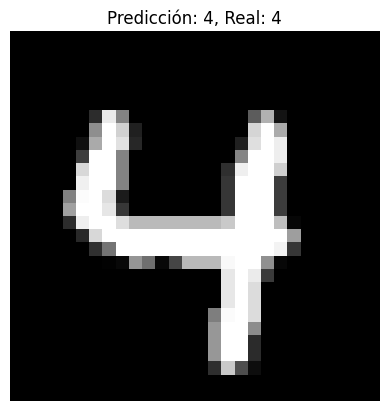

In [22]:
import matplotlib.pyplot as plt

# Seleccionamos un índice aleatorio del conjunto de prueba
idx = 2

# Obtenemos la imagen y la etiqueta real
image = test_images[idx]
true_label = test_labels[idx]

# Hacemos una predicción con el modelo
prediction_logits = predict(params, image.reshape(1, -1))
predicted_label = jnp.argmax(prediction_logits, axis=-1)[0]

# Mostramos la imagen
plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicción: {predicted_label}, Real: {true_label}")
plt.axis('off')
plt.show()